In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
import joblib  # to save the model

UPLOADING THE CSV

In [ ]:
from google.colab import files
uploaded = files.upload()
# → A "Choose Files" button will appear → select your CSV file

Saving final_training_data.csv to final_training_data.csv


In [ ]:
import pandas as pd
df = pd.read_csv("final_training_data.csv")
print(df.shape)

(1921, 52)


CHECKING NO.OF NANS

In [ ]:
print("\n--- NaN Check ---")
print(df.isnull().sum())
print(f"Total NaNs: {df.isnull().sum().sum()}")


--- NaN Check ---
right_knee_y              0
direction               661
cumulative_distance    1260
straight_distance      1260
acceleration           1260
right_ankle_y             0
dx                        0
left_hip_x                0
recovery_time          1260
right_hip_x               0
left_ankle_y              0
movement_range_y       1260
right_knee_x              0
left_hip_y                0
stance_width              0
frame                     0
source_video              0
rolling_speed_mean     1260
left_foot_y               0
centroid_y_smooth      1260
trajectory_angle       1260
right_foot_y              0
left_shoulder_y           0
left_shoulder_x           0
dy                        0
centroid_x_smooth      1260
speed_smoothed          661
right_foot_x              0
centroid_x             1260
right_ankle_x             0
right_shoulder_x          0
right_shoulder_y          0
recovery_distance       661
path_efficiency        1260
footwork_label            0
h

INFINITY CHECK

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\n--- Infinity Check ---")
print(np.isinf(df[numeric_cols]).sum())


--- Infinity Check ---
right_knee_y           0
cumulative_distance    0
straight_distance      0
acceleration           0
right_ankle_y          0
dx                     0
left_hip_x             0
recovery_time          0
right_hip_x            0
left_ankle_y           0
movement_range_y       0
right_knee_x           0
left_hip_y             0
stance_width           0
rolling_speed_mean     0
left_foot_y            0
centroid_y_smooth      0
trajectory_angle       0
right_foot_y           0
left_shoulder_y        0
left_shoulder_x        0
dy                     0
centroid_x_smooth      0
speed_smoothed         0
right_foot_x           0
centroid_x             0
right_ankle_x          0
right_shoulder_x       0
right_shoulder_y       0
recovery_distance      0
path_efficiency        0
hip_center_x           0
left_ankle_x           0
centroid_y             0
direction_change       0
right_hip_y            0
rolling_speed_std      0
movement_range_x       0
distance               0
h

In [ ]:
print("\n--- Class Distribution ---")
print(df['footwork_label'].value_counts())


--- Class Distribution ---
footwork_label
Forehand_Front        398
Backhand_Mid          313
Recovery_Ready        291
Backhand_Backcourt    283
Backhand_Front        226
Forehand_Mid          216
Forehand_Backcourt    194
Name: count, dtype: int64


FEATURES AND LABEL

In [ ]:
DROP_COLS = ['frame', 'source_video', 'footwork_label']
FEATURE_COLS = [col for col in df.columns if col not in DROP_COLS]

X = df[FEATURE_COLS]  # All numeric pose features
y = df['footwork_label']  # Target label

print(f"\nFeatures used ({len(FEATURE_COLS)}):", FEATURE_COLS)
print(f"Label column: footwork_label")
print(f"X shape: {X.shape}, y shape: {y.shape}")



Features used (49): ['right_knee_y', 'direction', 'cumulative_distance', 'straight_distance', 'acceleration', 'right_ankle_y', 'dx', 'left_hip_x', 'recovery_time', 'right_hip_x', 'left_ankle_y', 'movement_range_y', 'right_knee_x', 'left_hip_y', 'stance_width', 'rolling_speed_mean', 'left_foot_y', 'centroid_y_smooth', 'trajectory_angle', 'right_foot_y', 'left_shoulder_y', 'left_shoulder_x', 'dy', 'centroid_x_smooth', 'speed_smoothed', 'right_foot_x', 'centroid_x', 'right_ankle_x', 'right_shoulder_x', 'right_shoulder_y', 'recovery_distance', 'path_efficiency', 'hip_center_x', 'left_ankle_x', 'centroid_y', 'direction_change', 'right_hip_y', 'rolling_speed_std', 'movement_range_x', 'distance', 'hip_center_y', 'path_length', 'left_knee_y', 'left_foot_x', 'left_knee_x', 'direction_code', 'speed', 'court_zone', 'stability_index']
Label column: footwork_label
X shape: (1921, 49), y shape: (1921,)


ENCODING THE LABELS

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("--- Label Encoding Map ---")
for idx, name in enumerate(le.classes_):
    print(f"  {name} → {idx}")

--- Label Encoding Map ---
  Backhand_Backcourt → 0
  Backhand_Front → 1
  Backhand_Mid → 2
  Forehand_Backcourt → 3
  Forehand_Front → 4
  Forehand_Mid → 5
  Recovery_Ready → 6


SPLITTING THE DATA & TRAINING

In [ ]:
print('source_video' in df.columns)

True


/tmp/ipykernel_5647/2178258912.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filled = df.groupby('source_video', group_keys=False).apply(lambda g: g.ffill().bfill())
/tmp/ipykernel_5647/2178258912.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df.groupby('source_video', group_keys=False).apply(lambda g: g.ffill().bfill())


Class distribution:
 footwork_label
Forehand_Front        398
Backhand_Mid          313
Recovery_Ready        291
Backhand_Backcourt    283
Backhand_Front        226
Forehand_Mid          216
Forehand_Backcourt    194
Name: count, dtype: int64

Unique videos: 9
source_video
Badminton full court    332
open_video_trim_2       332
open_video_trim_3       332
open_video_mp_1         264
single_2_bb             191
multishuttlecock_bb     163
singles___5_bb          112
single_1_bb              98
doubles_bb               97
Name: count, dtype: int64

Training... please wait ⏳
✅ Training complete!

                     precision    recall  f1-score   support

Backhand_Backcourt       1.00      0.50      0.67         2
    Backhand_Front       0.76      1.00      0.87        45
      Backhand_Mid       0.84      1.00      0.91        16
Forehand_Backcourt       0.76      0.65      0.70        20
    Forehand_Front       1.00      0.96      0.98       103
      Forehand_Mid       0.85      0

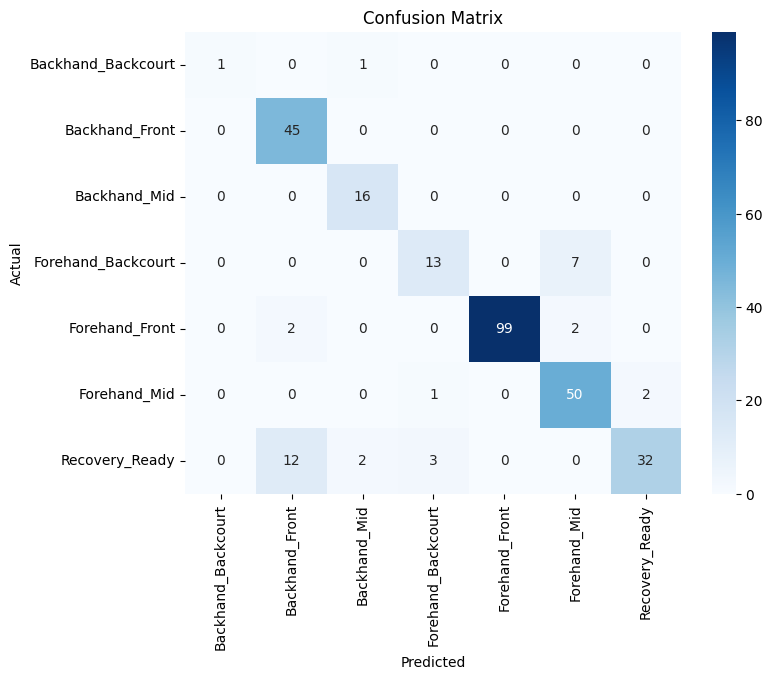


Top 15 features:
 right_hip_y        0.081602
left_hip_y         0.071915
hip_center_y       0.071908
hip_center_x       0.055368
right_hip_x        0.049395
right_knee_x       0.047729
left_hip_x         0.046539
court_zone         0.038513
left_knee_y        0.036167
right_foot_x       0.031986
right_ankle_x      0.031005
left_ankle_x       0.029645
left_shoulder_x    0.029105
left_knee_x        0.028556
left_foot_x        0.028348
dtype: float64


In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1 — Load raw data
df = pd.read_csv('final_training_data.csv')

# STEP 2 — Sort first
df = df.sort_values(['source_video', 'frame']).reset_index(drop=True)

# STEP 3 — Forward-fill, but do it safely without losing source_video
group_keys = df['source_video']  # save this BEFORE groupby just in case
df_filled = df.groupby('source_video', group_keys=False).apply(lambda g: g.ffill().bfill())
df = df_filled.fillna(0)

# Safety check: if source_video got dropped, put it back
if 'source_video' not in df.columns:
    df['source_video'] = group_keys.values

# STEP 4 — Sanity checks
print("Class distribution:\n", df['footwork_label'].value_counts())
print("\nUnique videos:", df['source_video'].nunique())
print(df['source_video'].value_counts())

# STEP 5 — Build X and y
X = df.drop(columns=['frame', 'source_video', 'footwork_label'])
y = df['footwork_label']

X['direction'] = X['direction'].fillna('UNKNOWN')
X = pd.get_dummies(X, columns=['direction'], drop_first=True)

if X['court_zone'].dtype == 'object':
    X['court_zone'] = X['court_zone'].fillna('UNKNOWN')
    X = pd.get_dummies(X, columns=['court_zone'], drop_first=True)

# STEP 6 — Grouped split by video
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['source_video']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# STEP 7 — Train
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("\nTraining... please wait ⏳")
rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# STEP 8 — Evaluate
y_pred = rf_model.predict(X_test)
print("\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# STEP 9 — Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.8889
Accuracy: 88.89%


SAVING THE MODEL

In [ ]:
import joblib

joblib.dump(rf_model, "Badminton_RF_Model.pkl")
joblib.dump(le, "Label_Encoder.pkl")
print("✅ Model saved as: badminton_rf_model.pkl")
print("✅ Label encoder saved as: label_encoder.pkl")

✅ Model saved as: badminton_rf_model.pkl
✅ Label encoder saved as: label_encoder.pkl


TO DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib

joblib.dump(rf_model, "/content/drive/MyDrive/Badminton_RF_Model.pkl")
joblib.dump(le, "/content/drive/MyDrive/Label_Encoder.pkl")

print("✅ badminton_rf_model.pkl saved to Drive!")
print("✅ label_encoder.pkl saved to Drive!")

✅ badminton_rf_model.pkl saved to Drive!
✅ label_encoder.pkl saved to Drive!
